In [ ]:
import pandas as pd

: 

In [ ]:
# Class 0: No Damage
# Class 1: Light Damage (cosmetic cracks)
# Class 2: Moderate Damage (Significant structural damage, some injuries)
# Class 3: Severe Damage (Widespread collapse, high casualty risk)
# Class 4: Collapse (Widespread collapse, high casualty risk)

Note: We will use a synthetic data with 15% noise 

In [4]:
# df = pd.read_csv('antipolo_poc_dataset_classes_0_to_4.csv')
df = pd.read_csv('antipolo_poc_dataset_noisy_realistic.csv')
print(df.shape)
df.head(3)

(5000, 16)


,bldg_id,barangay,latitude,longitude,year_built,floors,material,occupancy,vs30,event_id,magnitude,dist_km,pga_g,pgv_cms,damage_class,damage_severity
0,ANT-04629,San Luis,14.64637,121.20381,1958,8,Concrete,Industrial,507,EVT-069,5.1,55.24,0.130,15.6,1,Class 1: Light Damage
1,ANT-03318,San Luis,14.62849,121.17267,1967,5,Wood,Industrial,563,EVT-006,7.2,100.85,0.286,34.3,2,Class 2: Moderate Damage
2,ANT-04828,Dela Paz,14.58880,121.17573,2015,5,Steel,Residential,747,EVT-061,8.2,83.70,0.764,91.7,3,Class 3: Severe Damage


In [5]:
df.damage_class.value_counts()

damage_class
2    1028
3    1001
1     993
0     990
4     988
Name: count, dtype: int64

In [6]:
df.barangay.value_counts()

barangay
Cupang          469
Dela Paz        461
San Luis        447
San Juan        427
San Isidro      420
Bagong Nayon    411
Mayamot         410
Dalig           407
Muntindilaw     403
Inarawan        395
San Jose        386
San Roque       364
Name: count, dtype: int64

In [7]:
df.columns

Index(['bldg_id', 'barangay', 'latitude', 'longitude', 'year_built', 'floors',
       'material', 'occupancy', 'vs30', 'event_id', 'magnitude', 'dist_km',
       'pga_g', 'pgv_cms', 'damage_class', 'damage_severity'],
      dtype='object')

In [8]:
id_cols = ['bldg_id', 'event_id']
target_col = "damage_class"

# note: we keep 'barangay' as a categorical column here 
for_drop_cols = ['damage_severity', 'latitude', 'longitude']

numeric_cols = [
    'year_built', 
    'floors', 
    'vs30', 
    'magnitude', 
    'dist_km', 
    'pga_g', 
    'pgv_cms'
]


categorical_cols = [
    'barangay', 
    'material', 
    'occupancy'
]

binary_cols = [
    # Left empty. There are no boolean (True/False) or 0/1 features in this specific dataset schema.
]

(Note on barangay: We keep this as a categorical feature, It makes your model strictly "Antipolo-specific." If we drop it, your model relies entirely on universal physics and materials, meaning a model trained on Antipolo data could be deployed in other places like Manila. For a generalized Proof of Concept, it is usually better to drop the barangay but here I want to be specific in Antipolo).

In [9]:
drop_cols = id_cols + [target_col] + for_drop_cols

X = df.drop(columns=drop_cols)
y = df[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5000, 10)
y shape: (5000,)


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
                                                      X,
                                                      y,
                                                      test_size=0.20,
                                                      random_state=42,
                                                      stratify=y # ensure balance distribution of samples
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (4000, 10)
X_test shape: (1000, 10)
y_train shape: (4000,)
y_test shape: (1000,)


In [11]:
## NEW CODE (Cleaner)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler

# 1. Combine your lists of column names into one
all_categorical_cols = categorical_cols + binary_cols

# 2. Build the cleaner preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num", RobustScaler(), numeric_cols),
        ("cat_all", OneHotEncoder(drop="if_binary",
                                  handle_unknown="ignore" #safety net to handle unknown class category so the model will not crash
                                  ), all_categorical_cols)
    ]
)

preprocessor

,transformers,"[('num', ...), ('cat_all', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,with_centering,True
,with_scaling,True
,quantile_range,"(25.0, ...)"


In [12]:

from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

# 1. Instantiate the XGBoost model
model_xgb = XGBClassifier(
    random_state=42,
    # scale_pos_weight= dynamic_weight,  # The ratio of (majority class count / minority class count) to handle the imbalance
    tree_method='hist'    # Highly recommended: uses the same speed-optimized binning as HistGradientBoosting
)


In [13]:

# 2. Build the unified pipeline
pipeline_xgb = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", model_xgb)
])

# 3. Fit and predict (the pipeline handles passing the transformed data automatically)
pipeline_xgb.fit(X_train, y_train)


,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat_all', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [14]:
y_pred_xgb = pipeline_xgb.predict(X_test)

In [15]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model(y_test, y_pred, model_name="Model"):
    """
    Print accuracy, classification report, and plot confusion matrix.

    Parameters:
        y_test: True labels
        y_pred: Predicted labels
        model_name: Title for the plot (e.g., "Random Forest")
    """
    # 1. Accuracy
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

    # 2. Classification Report
    print("\nClassification Report:")
    print(classification_report(
        y_test,
        y_pred,
    ))

    # 3. Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues")

    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.tight_layout()
    plt.show()

    return cm

Accuracy: 0.8000

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.92      0.90       198
           1       0.76      0.75      0.75       198
           2       0.76      0.70      0.73       206
           3       0.74      0.76      0.75       200
           4       0.86      0.87      0.87       198

    accuracy                           0.80      1000
   macro avg       0.80      0.80      0.80      1000
weighted avg       0.80      0.80      0.80      1000



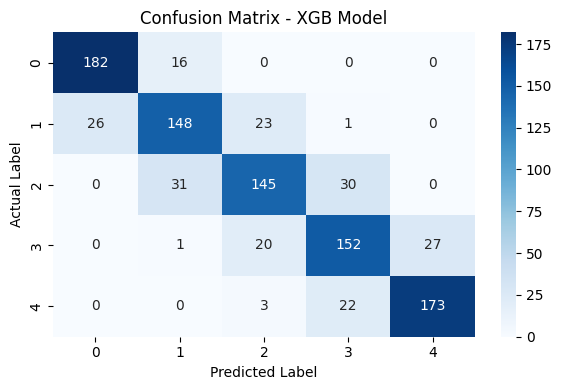

array([[182,  16,   0,   0,   0],
       [ 26, 148,  23,   1,   0],
       [  0,  31, 145,  30,   0],
       [  0,   1,  20, 152,  27],
       [  0,   0,   3,  22, 173]])

In [16]:
evaluate_model(y_test,
               y_pred_xgb,
               model_name="XGB Model"
               )

# Improve Recall


In [19]:
# !pip install optuna

In [17]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

In [18]:
#########################
## XGBoost for Recall
#########################

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

In [19]:
import numpy as np
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
import optuna

def objective(trial):
    # 1. Define the hyperparameter search space for XGBoost
    # Focusing on constraints to prevent overfitting on smaller datasets
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 300),
        "max_depth": trial.suggest_int("max_depth", 3, 7),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 5),

        # Static parameters (Not tuned)
        # "scale_pos_weight": dynamic_weight,
        "tree_method": "hist",
        "random_state": 42
    }

    # 2. Instantiate the XGBoost model with the suggested dictionary
    xgb_model = XGBClassifier(**params)

    # 3. Build the pipeline
    model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", xgb_model)
    ])


    #######################################
    #### SCORING = RECALL
    #######################################
    # 4. Evaluate using Cross-Validation
    try:
        scores = cross_val_score(
            model,
            X_train,
            y_train,
            cv=cv,
            scoring="recall", # Prioritizing catching the anomalies/denials
            n_jobs=-1
        )

        if np.isnan(scores).any():
            return 0.0

        return scores.mean()

    except Exception as e:
        print(f"Trial failed. Error: {e}")
        return 0.0


e:\0_AI_2025\ML_Classification\Earthquake\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [20]:
study = optuna.create_study(direction="maximize")

[I 2026-06-28 13:59:48,870] A new study created in memory with name: no-name-127cbac5-41f8-46d7-8770-1b7d9a078492


In [21]:
study.optimize(objective, n_trials=5)

[I 2026-06-28 13:59:55,453] Trial 0 finished with value: 0.0 and parameters: {'n_estimators': 218, 'max_depth': 6, 'learning_rate': 0.02130857791512407, 'subsample': 0.9031234668378869, 'colsample_bytree': 0.9990642168097041, 'min_child_weight': 1}. Best is trial 0 with value: 0.0.
[I 2026-06-28 13:59:57,896] Trial 1 finished with value: 0.0 and parameters: {'n_estimators': 64, 'max_depth': 5, 'learning_rate': 0.0524294299786341, 'subsample': 0.8161044815747563, 'colsample_bytree': 0.6404548538156352, 'min_child_weight': 1}. Best is trial 0 with value: 0.0.
[I 2026-06-28 14:00:01,536] Trial 2 finished with value: 0.0 and parameters: {'n_estimators': 234, 'max_depth': 7, 'learning_rate': 0.014990388192162665, 'subsample': 0.6990938906643636, 'colsample_bytree': 0.6474687561825094, 'min_child_weight': 2}. Best is trial 0 with value: 0.0.
[I 2026-06-28 14:00:03,873] Trial 3 finished with value: 0.0 and parameters: {'n_estimators': 59, 'max_depth': 4, 'learning_rate': 0.014363594378351321,

In [22]:
study.best_params

{'n_estimators': 218,
 'max_depth': 6,
 'learning_rate': 0.02130857791512407,
 'subsample': 0.9031234668378869,
 'colsample_bytree': 0.9990642168097041,
 'min_child_weight': 1}

In [23]:
# 1. Instantiate the model using the best parameters from your Optuna study
# **study.best_params automatically unpacks all the tuned hyperparameters
model_xgb_tuned_recall          = XGBClassifier(
                                **study.best_params,

                                # Keep your static pipeline settings here
                                # scale_pos_weight=dynamic_weight,
                                tree_method='hist',
                                random_state=42
)

# 2. Re-build your final production pipeline with this tuned model
pipeline_xgb_tuned_recall = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", model_xgb_tuned_recall)
])

# 3. Fit on your entire training set
pipeline_xgb_tuned_recall.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat_all', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Accuracy: 0.8320

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.94      0.92       198
           1       0.80      0.78      0.79       198
           2       0.79      0.74      0.77       206
           3       0.78      0.81      0.79       200
           4       0.89      0.89      0.89       198

    accuracy                           0.83      1000
   macro avg       0.83      0.83      0.83      1000
weighted avg       0.83      0.83      0.83      1000



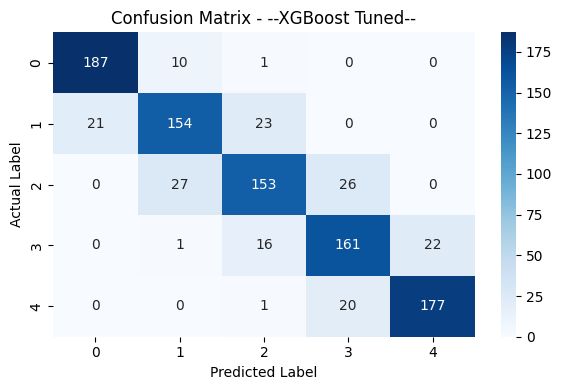

array([[187,  10,   1,   0,   0],
       [ 21, 154,  23,   0,   0],
       [  0,  27, 153,  26,   0],
       [  0,   1,  16, 161,  22],
       [  0,   0,   1,  20, 177]])

In [29]:
evaluate_model(y_test,
               pipeline_xgb_tuned_recall.predict(X_test),
               model_name="--XGBoost Tuned--"
               )

---

# Download the model

----

# Thresholding a Multi-Classification Model

## The Post-Prediction Rule (Custom Heuristics)

In [30]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

In [39]:
# Get raw probabilities for all 5 classes instead of final predictions
probs = pipeline_xgb_tuned_recall.predict_proba(X_test)

final_predictions = []
for p in probs:
    # p[3] is prob of Class 3, p[4] is prob of Class 4
    high_risk_prob = p[3] + p[4] 
    
    if high_risk_prob >= 0.25:  # Custom tuned threshold for safety
        # Force the prediction to be either 3 or 4 (whichever is higher)
        final_predictions.append(3 if p[3] > p[4] else 4)
        # final_predictions.append(4)
    else:
        # Otherwise, just pick the highest probability normally (argmax)
        final_predictions.append(np.argmax(p))

Accuracy: 0.8230

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.94      0.92       198
           1       0.80      0.78      0.79       198
           2       0.83      0.65      0.73       206
           3       0.72      0.85      0.78       200
           4       0.89      0.89      0.89       198

    accuracy                           0.82      1000
   macro avg       0.83      0.82      0.82      1000
weighted avg       0.83      0.82      0.82      1000



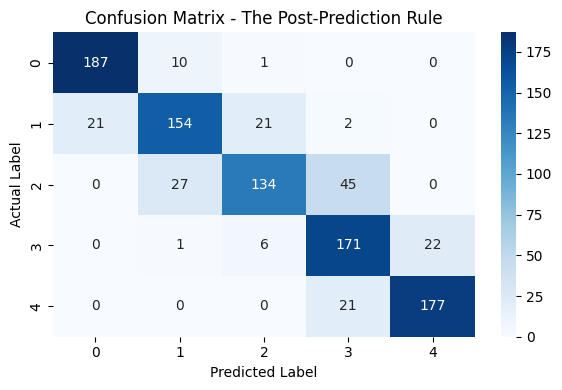

array([[187,  10,   1,   0,   0],
       [ 21, 154,  21,   2,   0],
       [  0,  27, 134,  45,   0],
       [  0,   1,   6, 171,  22],
       [  0,   0,   0,  21, 177]])

In [40]:
evaluate_model(y_test, final_predictions, 'The Post-Prediction Rule')

## Class Weighting (Tuning during Training)

This class weight is baked in our model

In [78]:
# Give higher weights to classes 3 and 4
weight_dict = {0: 1.0,
               1: 1.0,
               2: 1.0,
               3: 2.0,
               4: 100.0
               }

# Generate an array of weights for your training data
sample_weights = y_train.map(weight_dict)

In [85]:
# preprocessor

In [86]:
# model_xgb_tuned_recall

In [87]:
# pipeline_xgb_tuned_recall

In [80]:
from sklearn.pipeline import Pipeline

# refit
pipeline_xgb_tuned_recall.fit(
    X_train, 
    y_train,
    model__sample_weight=sample_weights.values
)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat_all', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Download it now..


In [84]:
import joblib

# Save the entire pipeline
joblib.dump(pipeline_xgb_tuned_recall, 'pipeline_xgb_tuned_recall_threshold.pkl')

# # Load and predict later
# loaded_pipeline = joblib.load('pipeline_xgb_tuned_recall.pkl')
# predictions = loaded_pipeline.predict(new_data)  # Preprocessing happens automatically

['pipeline_xgb_tuned_recall_threshold.pkl']

Testing ...

In [81]:
preds_with_weight = pipeline_xgb_tuned_recall.predict_proba(X_test)

In [82]:
final_predictions = []

for p in preds_with_weight:
    final_predictions.append(np.argmax(p))

In [58]:
# final_predictions

Accuracy: 0.7490

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.92      0.90       198
           1       0.78      0.78      0.78       198
           2       0.80      0.68      0.74       206
           3       0.76      0.41      0.53       200
           4       0.61      0.95      0.74       198

    accuracy                           0.75      1000
   macro avg       0.77      0.75      0.74      1000
weighted avg       0.77      0.75      0.74      1000



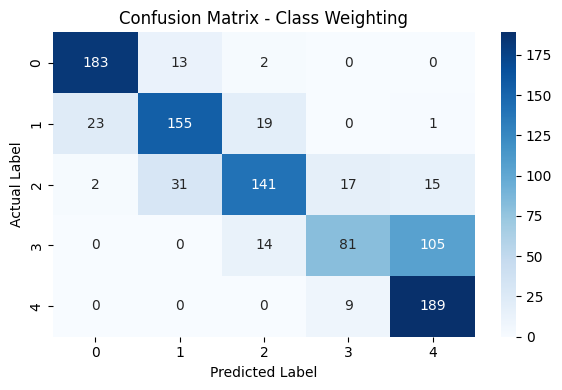

array([[183,  13,   2,   0,   0],
       [ 23, 155,  19,   0,   1],
       [  2,  31, 141,  17,  15],
       [  0,   0,  14,  81, 105],
       [  0,   0,   0,   9, 189]])

In [83]:
evaluate_model(y_test, final_predictions, 'Class Weighting')

-- end --